# 05 — Convolutional Neural Network on Image Data (CIFAR-10)

**Goal:** switch from tabular data to images and repeat the same core experiment — does the
"data size vs. performance" relationship we saw for tabular models also hold for a CNN trained on
images? We'll train a CNN from scratch on small / medium / large subsets of CIFAR-10.

**Dataset:** CIFAR-10 — 60,000 32×32 color images across 10 classes (airplane, car, bird, cat,
deer, dog, frog, horse, ship, truck).

**Concepts applied here:** convolution and pooling layers, CNN architecture design,
and the same regularization/optimization toolkit (dropout, batch norm, Adam, early stopping) applied to a very different data type.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

os.makedirs("../data/processed", exist_ok=True)

## 1. Load CIFAR-10 and look at some examples

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
print("Train:", X_train_full.shape, "Test:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2150s 13us/step
Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)


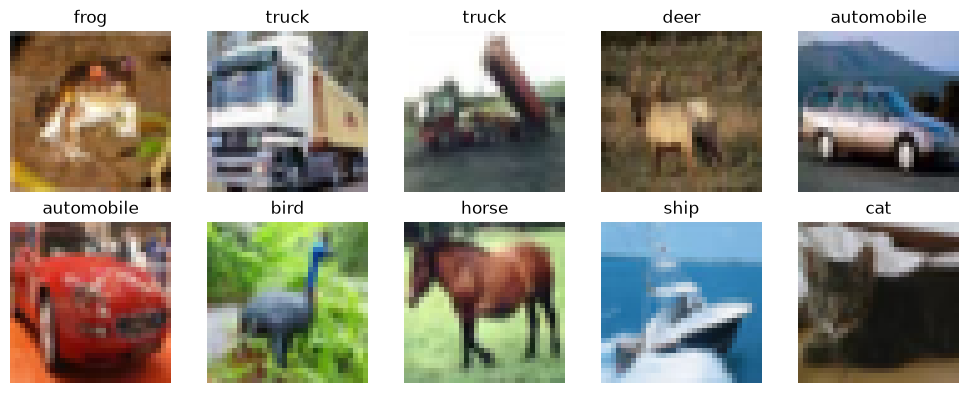

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i])
    ax.set_title(class_names[y_train_full[i]])
    ax.axis("off")
plt.tight_layout()
plt.savefig("../results/figures/cifar10_examples.png", dpi=150)
plt.show()

## 2. Preprocess: normalize pixels, carve out a validation set, and build small/medium/large
training subsets (same design as Notebook 01, just for images this time)

In [7]:
# Normalize pixel values to [0, 1]
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Carve a validation set out of the training pool (stratified)
from sklearn.model_selection import train_test_split
X_train_pool, X_val, y_train_pool, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, stratify=y_train_full, random_state=RANDOM_STATE
)

def stratified_subsample_images(X, y, n_per_class, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    idxs = []
    for c in np.unique(y):
        class_idx = np.where(y == c)[0]
        chosen = rng.choice(class_idx, size=min(n_per_class, len(class_idx)), replace=False)
        idxs.append(chosen)
    idxs = np.concatenate(idxs)
    rng.shuffle(idxs)
    return X[idxs], y[idxs]

# ~10 classes, so n_per_class * 10 = total training set size
IMAGE_SIZES = {"small": 100, "medium": 1000, "large": 4500}   # images PER CLASS

image_subsets = {}
for name, n_per_class in IMAGE_SIZES.items():
    Xs, ys = stratified_subsample_images(X_train_pool, y_train_pool, n_per_class)
    image_subsets[name] = (Xs, ys)
    print(f"{name}: {Xs.shape[0]} images total")

small: 1000 images total
medium: 10000 images total
large: 45000 images total


## 3. CNN architecture

A compact but standard CNN: two Conv→BatchNorm→ReLU→MaxPool blocks, then a dense classifier head
with dropout.

In [8]:
def build_cnn(input_shape=(32,32,3), num_classes=10, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

build_cnn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

## 4. Train the CNN on each dataset size


In [9]:
cnn_rows = []
cnn_histories = {}
cnn_models = {}

for size_name, (X_tr, y_tr) in image_subsets.items():
    model = build_cnn()
    early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    t0 = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=40,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0,
    )
    train_time = time.time() - t0
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    cnn_models[size_name] = model
    cnn_histories[size_name] = history
    cnn_rows.append({
        "model": "CNN_from_scratch", "dataset_size_name": size_name,
        "n_train": X_tr.shape[0], "val_accuracy": val_acc,
        "train_time_sec": train_time, "n_epochs_ran": len(history.history["loss"]),
    })
    print(f"{size_name} (n={X_tr.shape[0]}): val_acc={val_acc:.3f}, time={train_time:.1f}s")

cnn_results = pd.DataFrame(cnn_rows)
cnn_results

small (n=1000): val_acc=0.135, time=13.8s
medium (n=10000): val_acc=0.515, time=76.3s
large (n=45000): val_acc=0.663, time=410.6s


,model,dataset_size_name,n_train,val_accuracy,train_time_sec,n_epochs_ran
0,CNN_from_scratch,small,1000,0.1348,13.807728,11
1,CNN_from_scratch,medium,10000,0.5148,76.347977,17
2,CNN_from_scratch,large,45000,0.6626,410.645260,24


## 5. Accuracy vs. training set size (image classification)

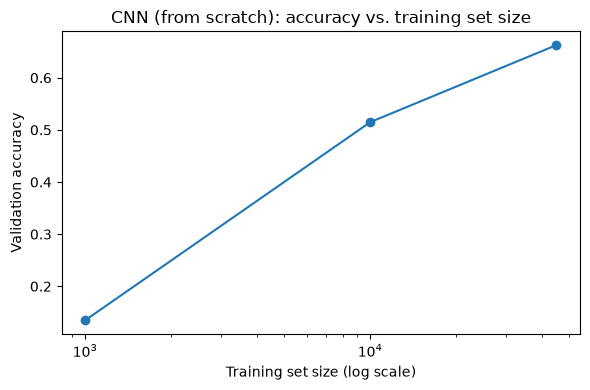

In [10]:
plt.figure(figsize=(6,4))
plt.plot(cnn_results["n_train"], cnn_results["val_accuracy"], marker="o")
plt.xscale("log")
plt.xlabel("Training set size (log scale)")
plt.ylabel("Validation accuracy")
plt.title("CNN (from scratch): accuracy vs. training set size")
plt.tight_layout()
plt.savefig("../results/figures/cnn_accuracy_vs_size.png", dpi=150)
plt.show()

## 6. Look at some misclassified examples (error analysis)

Looking at *what* the model
gets wrong, not just the aggregate accuracy number, often reveals something worth discussing.

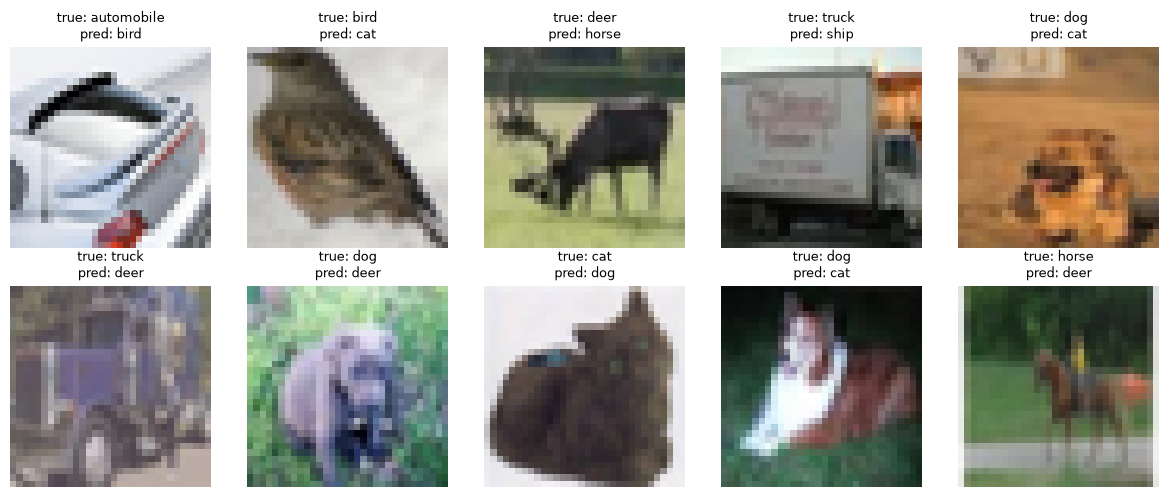

In [11]:
best_size = cnn_results.loc[cnn_results["val_accuracy"].idxmax(), "dataset_size_name"]
best_cnn = cnn_models[best_size]

val_probs = best_cnn.predict(X_val, verbose=0)
val_preds = val_probs.argmax(axis=1)
wrong_idx = np.where(val_preds != y_val)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.RandomState(RANDOM_STATE)
sample_wrong = rng.choice(wrong_idx, size=10, replace=False)
for ax, idx in zip(axes.flat, sample_wrong):
    ax.imshow(X_val[idx])
    ax.set_title(f"true: {class_names[y_val[idx]]}\npred: {class_names[val_preds[idx]]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("../results/figures/cnn_misclassified_examples.png", dpi=150)
plt.show()

In [12]:
cnn_results.to_csv("../results/cnn_metrics.csv", index=False)

# Save the small-subset data and the from-scratch small-subset model's accuracy for
# Notebook 06's transfer-learning comparison
import joblib
joblib.dump({
    "image_subsets": image_subsets, "X_val": X_val, "y_val": y_val,
    "X_test": X_test, "y_test": y_test, "class_names": class_names,
}, "../data/processed/image_data.joblib")
print("Saved.")

Saved.


## Summary

We trained a CNN from scratch on three image-dataset sizes, observed how accuracy scales with data,
and did a quick qualitative error analysis.